# CleanAir AI — Notebook 01: Live AQI Data Fetching

This notebook performs the first data-engineering and ML-preparation stage of CleanAir AI.

## Objectives

1. Load the CPCB/data.gov.in API key safely from `.env`.
2. Fetch live AQI pollutant data from the CPCB API.
3. Clean and standardize the data.
4. Convert pollutant-level data into station-level data.
5. Calculate pollutant AQI sub-index values.
6. Calculate raw AQI, AQI category, and dominant pollutant.
7. Apply AQI validity checks.
8. Create safer reported AQI values.
9. Save latest station intelligence.
10. Maintain an append-only AQI history file.
11. Create city-level AQI summary.

## Main outputs

- `data/raw/cpcb_aqi_clean_long.csv`
- `data/processed/station_intelligence_latest.csv`
- `data/processed/station_aqi_history.csv`
- `data/processed/city_aqi_summary_latest.csv`
- `outputs/top_cities_by_mean_aqi.png`
- `reports/notebook_01_run_summary.json`

In [2]:
from pathlib import Path
from datetime import datetime
from getpass import getpass

import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    CACHE_DIR,
    OUTPUTS_DIR,
    MODELS_DIR,
    REPORTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw folder:", RAW_DIR)
print("Processed folder:", PROCESSED_DIR)
print("Cache folder:", CACHE_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: C:\Users\Lenovo\Desktop\CleanAir_AI
Raw folder: C:\Users\Lenovo\Desktop\CleanAir_AI\data\raw
Processed folder: C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed
Cache folder: C:\Users\Lenovo\Desktop\CleanAir_AI\data\cache
Outputs folder: C:\Users\Lenovo\Desktop\CleanAir_AI\outputs
Reports folder: C:\Users\Lenovo\Desktop\CleanAir_AI\reports


In [4]:
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(dotenv_path=ENV_PATH)

CPCB_API_KEY = os.getenv("CPCB_API_KEY", "").strip()

if not CPCB_API_KEY:
    CPCB_API_KEY = getpass(
        "CPCB_API_KEY was not found in .env. Paste your API key securely: "
    ).strip()

if not CPCB_API_KEY:
    raise ValueError("No CPCB API key was provided.")

print("CPCB API key loaded successfully.")
print("Key length:", len(CPCB_API_KEY))

CPCB API key loaded successfully.
Key length: 56


In [5]:
API_URL = "https://api.data.gov.in/resource/3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69"

PAGE_LIMIT = 500
REQUEST_TIMEOUT = 180
MAX_RETRIES = 5

print("API endpoint configured.")

API endpoint configured.


In [6]:
def request_api_page(offset, limit=500, max_retries=5):
    """
    Fetch one page from the CPCB/data.gov.in AQI API.
    Uses retry logic, browser-like headers, and longer timeout.
    """

    params = {
        "api-key": CPCB_API_KEY,
        "format": "json",
        "offset": offset,
        "limit": limit
    }

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/120.0 Safari/537.36"
        ),
        "Accept": "application/json,text/plain,*/*",
        "Connection": "close"
    }

    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            print(
                f"Requesting offset={offset}, "
                f"limit={limit}, "
                f"attempt={attempt}/{max_retries}"
            )

            response = requests.get(
                API_URL,
                params=params,
                headers=headers,
                timeout=(20, REQUEST_TIMEOUT)
            )

            response.raise_for_status()

            payload = response.json()

            if not isinstance(payload, dict):
                raise ValueError("API response is not a JSON dictionary.")

            return payload

        except Exception as exc:
            last_error = exc
            print(f"Attempt {attempt}/{max_retries} failed: {exc}")

            if attempt < max_retries:
                sleep_time = 5 * attempt
                print(f"Waiting {sleep_time} seconds before retry...")
                time.sleep(sleep_time)

    raise RuntimeError(f"API request failed. Last error: {last_error}")

In [7]:
test_payload = request_api_page(
    offset=0,
    limit=1,
    max_retries=5
)

print("Response keys:", list(test_payload.keys()))
print("Total records:", test_payload.get("total"))
print("Records returned:", len(test_payload.get("records", [])))

if test_payload.get("records"):
    print("API test successful.")
else:
    print("API responded, but no records were returned.")

Requesting offset=0, limit=1, attempt=1/5


Response keys: ['index_name', 'title', 'desc', 'org_type', 'org', 'sector', 'source', 'catalog_uuid', 'visualizable', 'active', 'created', 'updated', 'created_date', 'updated_date', 'external_ws', 'external_ws_url', 'target_bucket', 'field', 'message', 'version', 'status', 'total', 'count', 'limit', 'offset', 'records']
Total records: 3507
Records returned: 1
API test successful.


In [8]:
records = test_payload.get("records", [])

if len(records) == 0:
    raise ValueError("No records returned. Check your API key or API URL.")

print(json.dumps(records[0], indent=2, ensure_ascii=False))

{
  "country": "India",
  "state": "Assam",
  "city": "Guwahati",
  "station": "Pan Bazaar, Guwahati - PCBA",
  "last_update": "16-07-2026 05:00:00",
  "latitude": "26.1875",
  "longitude": "91.744194",
  "pollutant_id": "NH3",
  "min_value": "1",
  "max_value": "1",
  "avg_value": "1"
}


In [9]:
def fetch_all_aqi_records(page_limit=500):
    """
    Download all records currently available from the API.
    Smaller pages reduce timeout risk.
    """

    first_payload = request_api_page(
        offset=0,
        limit=page_limit,
        max_retries=MAX_RETRIES
    )

    total_records = int(first_payload.get("total", 0))
    all_records = first_payload.get("records", [])

    print(f"API total records: {total_records:,}")
    print(f"Downloaded first page: {len(all_records):,}")

    if total_records <= len(all_records):
        return all_records

    for offset in tqdm(
        range(page_limit, total_records, page_limit),
        desc="Downloading pages"
    ):
        payload = request_api_page(
            offset=offset,
            limit=page_limit,
            max_retries=MAX_RETRIES
        )

        page_records = payload.get("records", [])

        if not page_records:
            print(f"No records found at offset={offset}. Stopping.")
            break

        all_records.extend(page_records)
        time.sleep(0.5)

    print(f"Total downloaded records: {len(all_records):,}")

    return all_records

In [10]:
RAW_CACHE_PATH = CACHE_DIR / "cpcb_aqi_raw_latest.csv"

try:
    raw_records = fetch_all_aqi_records(page_limit=PAGE_LIMIT)

    raw_df = pd.DataFrame(raw_records)

    if raw_df.empty:
        raise ValueError("API returned an empty dataframe.")

    raw_df.to_csv(RAW_CACHE_PATH, index=False)

    print("Live API data downloaded successfully.")
    print("Saved raw cache to:", RAW_CACHE_PATH)

except Exception as api_error:
    print("Live API fetch failed:", api_error)

    if RAW_CACHE_PATH.exists():
        print("Using last cached AQI file.")
        raw_df = pd.read_csv(RAW_CACHE_PATH)
    else:
        raise RuntimeError(
            "API failed and no cache exists. Check API key, internet, and endpoint."
        ) from api_error

print("Raw dataframe shape:", raw_df.shape)
display(raw_df.head())

Requesting offset=0, limit=500, attempt=1/5


API total records: 3,507
Downloaded first page: 500


Requesting offset=500, limit=500, attempt=1/5


Requesting offset=1000, limit=500, attempt=1/5


Requesting offset=1500, limit=500, attempt=1/5


...

Requesting offset=2500, limit=500, attempt=1/5


Requesting offset=3000, limit=500, attempt=1/5


Requesting offset=3500, limit=500, attempt=1/5


Total downloaded records: 3,507
Live API data downloaded successfully.
Saved raw cache to: C:\Users\Lenovo\Desktop\CleanAir_AI\data\cache\cpcb_aqi_raw_latest.csv
Raw dataframe shape: (3507, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
0,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",16-07-2026 05:00:00,26.446912,91.439057,NH3,6,6,6
1,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",16-07-2026 05:00:00,26.446912,91.439057,CO,20,23,21
2,India,Assam,Silchar,"Tarapur, Silchar - PCBA",16-07-2026 05:00:00,24.82827,92.79525,SO2,4,6,5
3,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",16-07-2026 05:00:00,26.987634,94.636574,NO2,7,16,12
4,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",16-07-2026 05:00:00,26.146529,87.454184,NO2,10,22,15


In [11]:
raw_df.columns = (
    raw_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Columns after basic cleaning:")
print(raw_df.columns.tolist())

Columns after basic cleaning:
['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'min_value', 'max_value', 'avg_value']


In [12]:
COLUMN_ALIASES = {
    "station": "station_name",
    "station_name": "station_name",

    "last_update": "timestamp",
    "last_updated": "timestamp",

    "latitude": "lat",
    "lat": "lat",

    "longitude": "lon",
    "long": "lon",
    "lng": "lon",
    "lon": "lon",

    "pollutant_id": "pollutant",
    "pollutant": "pollutant",

    "avg_value": "pollutant_value",
    "pollutant_avg": "pollutant_value",
    "pollutant_average": "pollutant_value",
    "pollutant_value": "pollutant_value"
}

rename_map = {
    old_col: new_col
    for old_col, new_col in COLUMN_ALIASES.items()
    if old_col in raw_df.columns
}

raw_df = raw_df.rename(columns=rename_map)

print("Columns after alias mapping:")
print(raw_df.columns.tolist())

Columns after alias mapping:
['country', 'state', 'city', 'station_name', 'timestamp', 'lat', 'lon', 'pollutant', 'min_value', 'max_value', 'pollutant_value']


In [13]:
required_columns = [
    "station_name",
    "city",
    "state",
    "timestamp",
    "lat",
    "lon",
    "pollutant",
    "pollutant_value"
]

missing_columns = [
    col for col in required_columns
    if col not in raw_df.columns
]

if missing_columns:
    print("Available columns:")
    print(raw_df.columns.tolist())
    raise KeyError(f"Missing required columns: {missing_columns}")

print("All required columns found.")

All required columns found.


In [14]:
aqi_long = raw_df[required_columns].copy()

text_columns = [
    "station_name",
    "city",
    "state",
    "pollutant"
]

for col in text_columns:
    aqi_long[col] = (
        aqi_long[col]
        .astype("string")
        .str.strip()
    )

for col in ["lat", "lon", "pollutant_value"]:
    aqi_long[col] = pd.to_numeric(
        aqi_long[col],
        errors="coerce"
    )

aqi_long["timestamp"] = pd.to_datetime(
    aqi_long["timestamp"],
    errors="coerce",
    dayfirst=True
)

aqi_long = aqi_long.dropna(
    subset=[
        "station_name",
        "city",
        "state",
        "timestamp",
        "pollutant",
        "pollutant_value"
    ]
)

aqi_long = aqi_long[
    aqi_long["pollutant_value"] >= 0
].copy()

aqi_long = aqi_long.drop_duplicates(
    subset=[
        "station_name",
        "city",
        "state",
        "timestamp",
        "pollutant"
    ],
    keep="last"
)

aqi_long = aqi_long.sort_values(
    ["state", "city", "station_name", "timestamp", "pollutant"]
).reset_index(drop=True)

print("Clean long-format shape:", aqi_long.shape)
display(aqi_long.head(10))

Clean long-format shape: (3220, 8)


,station_name,city,state,timestamp,lat,lon,pollutant,pollutant_value
0,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,CO,61.0
1,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,NH3,3.0
2,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,NO2,32.0
3,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,OZONE,13.0
4,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,PM10,172.0
5,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,PM2.5,54.0
6,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,2026-07-16 05:00:00,16.515083,80.518167,SO2,16.0
7,"Gulzarpet, Anantapur - APPCB",Anantapur,Andhra Pradesh,2026-07-16 05:00:00,14.675886,77.593027,CO,22.0
8,"Gulzarpet, Anantapur - APPCB",Anantapur,Andhra Pradesh,2026-07-16 05:00:00,14.675886,77.593027,NH3,3.0
9,"Gulzarpet, Anantapur - APPCB",Anantapur,Andhra Pradesh,2026-07-16 05:00:00,14.675886,77.593027,NO2,16.0


In [15]:
def standardize_pollutant_name(value):
    value = str(value).strip().upper()
    value = value.replace(" ", "")
    value = value.replace("_", "")
    value = value.replace(".", "")

    mapping = {
        "PM25": "PM2.5",
        "PM2,5": "PM2.5",
        "PM10": "PM10",
        "NO2": "NO2",
        "SO2": "SO2",
        "CO": "CO",
        "O3": "O3",
        "OZONE": "O3",
        "NH3": "NH3"
    }

    return mapping.get(value, value)


aqi_long["pollutant"] = aqi_long["pollutant"].apply(
    standardize_pollutant_name
)

SUPPORTED_POLLUTANTS = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "NH3"
]

aqi_long = aqi_long[
    aqi_long["pollutant"].isin(SUPPORTED_POLLUTANTS)
].copy()

print("Pollutant distribution:")
print(aqi_long["pollutant"].value_counts())

Pollutant distribution:
pollutant
CO       473
O3       471
NO2      470
PM10     467
PM2.5    463
SO2      448
NH3      428
Name: count, dtype: int64


In [16]:
CLEAN_LONG_PATH = RAW_DIR / "cpcb_aqi_clean_long.csv"

aqi_long.to_csv(CLEAN_LONG_PATH, index=False)

print("Saved clean long data to:", CLEAN_LONG_PATH)
print("Rows:", len(aqi_long))

Saved clean long data to: C:\Users\Lenovo\Desktop\CleanAir_AI\data\raw\cpcb_aqi_clean_long.csv
Rows: 3220


In [17]:
station_keys = [
    "station_name",
    "city",
    "state",
    "lat",
    "lon",
    "timestamp"
]

station_df = (
    aqi_long
    .pivot_table(
        index=station_keys,
        columns="pollutant",
        values="pollutant_value",
        aggfunc="mean"
    )
    .reset_index()
)

station_df.columns.name = None

for pollutant in SUPPORTED_POLLUTANTS:
    if pollutant not in station_df.columns:
        station_df[pollutant] = np.nan

station_df = station_df[
    station_keys + SUPPORTED_POLLUTANTS
]

print("Station-level dataframe shape:", station_df.shape)
display(station_df.head())

Station-level dataframe shape: (500, 13)


,station_name,city,state,lat,lon,timestamp,PM2.5,PM10,NO2,SO2,CO,O3,NH3
0,"32Bungalows, Bhilai - CECB",Bhilai,Chhattisgarh,21.194815,81.314770,2026-07-16 05:00:00,27.0,51.0,12.0,12.0,17.0,6.0,3.0
1,"AIIMS, Raipur - CECB",Raipur,Chhattisgarh,21.258815,81.578979,2026-07-16 05:00:00,NaN,NaN,NaN,NaN,18.0,9.0,NaN
2,"Adarsh Nagar, Jaipur - RSPCB",Jaipur,Rajasthan,26.902909,75.836858,2026-07-16 05:00:00,89.0,97.0,38.0,24.0,27.0,49.0,5.0
3,"Airport Area, Indore - IMC",Indore,Madhya Pradesh,22.728900,75.807600,2026-07-16 05:00:00,61.0,58.0,45.0,7.0,40.0,5.0,0.0
4,"Alipur, Delhi - DPCC",Delhi,Delhi,28.815329,77.153010,2026-07-16 05:00:00,73.0,180.0,62.0,10.0,36.0,4.0,16.0


In [18]:
AQI_BREAKPOINTS = {
    "PM2.5": [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 500, 401, 500)
    ],
    "PM10": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],
    "NO2": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 1000, 401, 500)
    ],
    "SO2": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2000, 401, 500)
    ],
    "CO": [
        (0, 1.0, 0, 50),
        (1.1, 2.0, 51, 100),
        (2.1, 10.0, 101, 200),
        (10.1, 17.0, 201, 300),
        (17.1, 34.0, 301, 400),
        (34.1, 50.0, 401, 500)
    ],
    "O3": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ],
    "NH3": [
        (0, 200, 0, 50),
        (201, 400, 51, 100),
        (401, 800, 101, 200),
        (801, 1200, 201, 300),
        (1201, 1800, 301, 400),
        (1801, 2400, 401, 500)
    ]
}

print("AQI breakpoint table created.")

AQI breakpoint table created.


In [19]:
def calculate_sub_index(concentration, pollutant):
    """
    Calculate CPCB-style AQI sub-index for one pollutant.
    """

    if pd.isna(concentration):
        return np.nan

    if pollutant not in AQI_BREAKPOINTS:
        return np.nan

    concentration = float(concentration)

    for bp_low, bp_high, index_low, index_high in AQI_BREAKPOINTS[pollutant]:
        if bp_low <= concentration <= bp_high:
            sub_index = (
                ((index_high - index_low) / (bp_high - bp_low))
                * (concentration - bp_low)
                + index_low
            )
            return round(sub_index, 2)

    return 500.0

In [20]:
def get_aqi_category(aqi):
    if pd.isna(aqi):
        return "Unknown"

    aqi = float(aqi)

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

In [21]:
for pollutant in SUPPORTED_POLLUTANTS:
    sub_index_col = f"{pollutant}_sub_index"

    station_df[sub_index_col] = station_df[pollutant].apply(
        lambda value: calculate_sub_index(value, pollutant)
    )

sub_index_columns = [
    f"{pollutant}_sub_index"
    for pollutant in SUPPORTED_POLLUTANTS
]

print("Sub-index columns created:")
print(sub_index_columns)

display(station_df[sub_index_columns].head())

Sub-index columns created:
['PM2.5_sub_index', 'PM10_sub_index', 'NO2_sub_index', 'SO2_sub_index', 'CO_sub_index', 'O3_sub_index', 'NH3_sub_index']


,PM2.5_sub_index,PM10_sub_index,NO2_sub_index,SO2_sub_index,CO_sub_index,O3_sub_index,NH3_sub_index
0,45.00,51.00,15.00,15.00,300.00,6.0,0.75
1,NaN,NaN,NaN,NaN,306.27,9.0,NaN
2,196.59,97.00,47.50,30.00,358.99,49.0,1.25
3,101.00,58.00,56.03,8.75,437.74,5.0,0.00
4,141.97,153.49,77.38,12.50,412.83,4.0,4.00


In [22]:
station_df["aqi"] = station_df[sub_index_columns].max(axis=1)

station_df["dominant_pollutant"] = station_df[sub_index_columns].idxmax(axis=1)

station_df["dominant_pollutant"] = (
    station_df["dominant_pollutant"]
    .str.replace("_sub_index", "", regex=False)
)

station_df.loc[
    station_df["aqi"].isna(),
    "dominant_pollutant"
] = np.nan

station_df["aqi_category"] = station_df["aqi"].apply(get_aqi_category)

station_df["snapshot_fetch_time"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

station_df["station_id"] = (
    station_df["state"].astype(str).str.lower().str.replace(r"\W+", "_", regex=True)
    + "__"
    + station_df["city"].astype(str).str.lower().str.replace(r"\W+", "_", regex=True)
    + "__"
    + station_df["station_name"].astype(str).str.lower().str.replace(r"\W+", "_", regex=True)
)

station_df = station_df.sort_values(
    ["state", "city", "station_name", "timestamp"]
).reset_index(drop=True)

print("Raw station AQI calculated.")

display(
    station_df[
        [
            "state",
            "city",
            "station_name",
            "timestamp",
            "aqi",
            "aqi_category",
            "dominant_pollutant"
        ]
    ].head(20)
)

Raw station AQI calculated.


,state,city,station_name,timestamp,aqi,aqi_category,dominant_pollutant
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-07-16 05:00:00,500.00,Severe,CO
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-07-16 05:00:00,329.70,Very Poor,CO
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-07-16 05:00:00,323.85,Very Poor,CO
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",2026-07-16 05:00:00,306.27,Very Poor,CO
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",2026-07-16 05:00:00,271.30,Poor,CO
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-16 05:00:00,364.85,Very Poor,CO
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",2026-07-16 05:00:00,174.94,Moderate,CO
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-16 05:00:00,317.99,Very Poor,CO
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-16 05:00:00,412.83,Severe,CO
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-16 05:00:00,353.14,Very Poor,CO


In [23]:
station_df["valid_pollutant_count"] = station_df[
    SUPPORTED_POLLUTANTS
].notna().sum(axis=1)

station_df["has_particulate"] = (
    station_df["PM2.5"].notna()
    | station_df["PM10"].notna()
)

station_df["aqi_is_valid"] = (
    (station_df["valid_pollutant_count"] >= 3)
    & (station_df["has_particulate"])
)

station_df["aqi_quality_flag"] = np.where(
    station_df["aqi_is_valid"],
    "Valid AQI",
    "Insufficient pollutants"
)

print("AQI validity distribution:")
print(station_df["aqi_quality_flag"].value_counts())

display(
    station_df[
        [
            "state",
            "city",
            "station_name",
            "valid_pollutant_count",
            "has_particulate",
            "aqi",
            "aqi_category",
            "dominant_pollutant",
            "aqi_quality_flag"
        ]
    ].head(20)
)

AQI validity distribution:
aqi_quality_flag
Valid AQI                  478
Insufficient pollutants     22
Name: count, dtype: int64


,state,city,station_name,valid_pollutant_count,has_particulate,aqi,aqi_category,dominant_pollutant,aqi_quality_flag
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",7,True,500.00,Severe,CO,Valid AQI
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",7,True,329.70,Very Poor,CO,Valid AQI
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",7,True,323.85,Very Poor,CO,Valid AQI
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",7,True,306.27,Very Poor,CO,Valid AQI
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",7,True,271.30,Poor,CO,Valid AQI
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",7,True,364.85,Very Poor,CO,Valid AQI
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",7,True,174.94,Moderate,CO,Valid AQI
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",7,True,317.99,Very Poor,CO,Valid AQI
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",7,True,412.83,Severe,CO,Valid AQI
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",7,True,353.14,Very Poor,CO,Valid AQI


In [24]:
station_df["reported_aqi"] = station_df["aqi"].where(
    station_df["aqi_is_valid"],
    np.nan
)

station_df["reported_aqi_category"] = station_df["reported_aqi"].apply(
    get_aqi_category
)

station_df["reported_dominant_pollutant"] = station_df["dominant_pollutant"].where(
    station_df["aqi_is_valid"],
    np.nan
)

print("Raw calculated AQI category distribution:")
print(station_df["aqi_category"].value_counts(dropna=False))

print("\nReported valid AQI category distribution:")
print(station_df["reported_aqi_category"].value_counts(dropna=False))

Raw calculated AQI category distribution:
aqi_category
Very Poor       192
Severe          153
Poor             87
Moderate         50
Satisfactory     12
Good              6
Name: count, dtype: int64

Reported valid AQI category distribution:
reported_aqi_category
Very Poor       183
Severe          147
Poor             84
Moderate         49
Unknown          22
Satisfactory     12
Good              3
Name: count, dtype: int64


In [25]:
print("Top 20 most polluted valid station records:")

display(
    station_df[
        station_df["aqi_is_valid"]
    ].sort_values("reported_aqi", ascending=False)[
        [
            "state",
            "city",
            "station_name",
            "timestamp",
            "reported_aqi",
            "reported_aqi_category",
            "reported_dominant_pollutant",
            "valid_pollutant_count",
            "PM2.5",
            "PM10",
            "NO2",
            "SO2",
            "CO",
            "O3",
            "NH3"
        ]
    ].head(20)
)

Top 20 most polluted valid station records:


,state,city,station_name,timestamp,reported_aqi,reported_aqi_category,reported_dominant_pollutant,valid_pollutant_count,PM2.5,PM10,NO2,SO2,CO,O3,NH3
35,Bihar,Chhapra,"Darshan Nagar, Chhapra - BSPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,72.0,111.0,2.0,21.0,85.0,3.0,11.0
450,Uttar Pradesh,Meerut,"Jai Bhim Nagar, Meerut - UPPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,44.0,123.0,21.0,4.0,64.0,11.0,6.0
33,Bihar,Bihar Sharif,"D M Colony, Bihar Sharif - BSPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,29.0,22.0,9.0,7.0,104.0,2.0,3.0
301,Maharashtra,Pune,"Panchawati_Pashan, Pune - IITM",2026-07-16 05:00:00,500.0,Severe,CO,5,28.0,54.0,9.0,NaN,68.0,2.0,NaN
299,Maharashtra,Pune,"Dhankawadi, Pune - IITM",2026-07-16 05:00:00,500.0,Severe,CO,5,29.0,58.0,23.0,NaN,79.0,2.0,NaN
316,Odisha,Angul,"Hakimapada, Angul - OSPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,32.0,70.0,20.0,24.0,64.0,14.0,3.0
53,Bihar,Purnia,"Mariam Nagar, Purnia - BSPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,57.0,45.0,6.0,16.0,56.0,21.0,2.0
50,Bihar,Patna,"Muradpur, Patna - BSPCB",2026-07-16 05:00:00,500.0,Severe,CO,7,44.0,84.0,3.0,12.0,54.0,10.0,5.0
78,Delhi,Delhi,"Ashok Vihar, Delhi - DPCC",2026-07-16 05:00:00,500.0,Severe,CO,7,85.0,174.0,25.0,12.0,51.0,5.0,5.0
137,Gujarat,Vadodara,"Bapunagar, Vadodara - Nexteng Enviro",2026-07-16 05:00:00,500.0,Severe,CO,7,46.0,54.0,12.0,6.0,96.0,4.0,2.0


In [26]:
LATEST_PATH = PROCESSED_DIR / "station_intelligence_latest.csv"

station_df.to_csv(LATEST_PATH, index=False)

print("Saved latest station intelligence file:")
print(LATEST_PATH)
print("Rows:", len(station_df))
print("Columns:", len(station_df.columns))

Saved latest station intelligence file:
C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_intelligence_latest.csv
Rows: 500
Columns: 32


In [27]:
HISTORY_PATH = PROCESSED_DIR / "station_aqi_history.csv"

history_columns = [
    "station_id",
    "station_name",
    "city",
    "state",
    "lat",
    "lon",
    "timestamp",
    "snapshot_fetch_time",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "NH3",
    "aqi",
    "aqi_category",
    "dominant_pollutant",
    "valid_pollutant_count",
    "has_particulate",
    "aqi_is_valid",
    "aqi_quality_flag",
    "reported_aqi",
    "reported_aqi_category",
    "reported_dominant_pollutant"
]

current_history = station_df[history_columns].copy()

current_history["timestamp"] = pd.to_datetime(
    current_history["timestamp"],
    errors="coerce"
)

if HISTORY_PATH.exists():
    old_history = pd.read_csv(HISTORY_PATH)

    old_history["timestamp"] = pd.to_datetime(
        old_history["timestamp"],
        errors="coerce"
    )

    for col in history_columns:
        if col not in old_history.columns:
            old_history[col] = np.nan

    old_history = old_history[history_columns]

    combined_history = pd.concat(
        [old_history, current_history],
        ignore_index=True
    )

else:
    combined_history = current_history.copy()

combined_history = combined_history.drop_duplicates(
    subset=[
        "station_id",
        "timestamp"
    ],
    keep="last"
)

combined_history = combined_history.sort_values(
    ["state", "city", "station_name", "timestamp"]
).reset_index(drop=True)

combined_history.to_csv(HISTORY_PATH, index=False)

print("Historical AQI file updated:")
print(HISTORY_PATH)
print("History rows:", len(combined_history))
print("Unique stations:", combined_history["station_id"].nunique())
print(
    "Date range:",
    combined_history["timestamp"].min(),
    "to",
    combined_history["timestamp"].max()
)

Historical AQI file updated:


C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_aqi_history.csv
History rows: 6072
Unique stations: 512
Date range: 2026-07-15 18:00:00 to 2026-07-16 05:00:00


In [28]:
city_summary = (
    station_df
    .groupby(["state", "city"], as_index=False)
    .agg(
        station_count=("station_id", "nunique"),
        valid_station_count=("aqi_is_valid", "sum"),
        mean_aqi=("reported_aqi", "mean"),
        max_aqi=("reported_aqi", "max"),
        severe_station_count=("reported_aqi_category", lambda x: (x == "Severe").sum()),
        very_poor_station_count=("reported_aqi_category", lambda x: (x == "Very Poor").sum()),
        poor_station_count=("reported_aqi_category", lambda x: (x == "Poor").sum())
    )
)

city_summary["mean_aqi"] = city_summary["mean_aqi"].round(2)
city_summary["max_aqi"] = city_summary["max_aqi"].round(2)

city_summary["city_risk_level"] = city_summary["mean_aqi"].apply(
    get_aqi_category
)

city_summary["data_quality"] = np.where(
    city_summary["valid_station_count"] > 0,
    "Valid station data available",
    "No valid AQI station after pollutant coverage check"
)

CITY_SUMMARY_PATH = PROCESSED_DIR / "city_aqi_summary_latest.csv"

city_summary.to_csv(CITY_SUMMARY_PATH, index=False)

print("Saved city AQI summary:")
print(CITY_SUMMARY_PATH)

print("\nCity-level AQI risk distribution:")
print(city_summary["city_risk_level"].value_counts(dropna=False))

display(
    city_summary.sort_values("mean_aqi", ascending=False).head(20)
)

Saved city AQI summary:
C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\city_aqi_summary_latest.csv

City-level AQI risk distribution:
city_risk_level
Very Poor       102
Severe           63
Poor             59
Moderate         25
Unknown          12
Satisfactory      5
Name: count, dtype: int64


,state,city,station_count,valid_station_count,mean_aqi,max_aqi,severe_station_count,very_poor_station_count,poor_station_count,city_risk_level,data_quality
0,Andhra Pradesh,Amaravati,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
14,Assam,Byrnihat,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
26,Bihar,Bihar Sharif,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
28,Bihar,Chhapra,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
31,Bihar,Katihar,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
38,Bihar,Purnia,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
64,Haryana,Ambala,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
56,Gujarat,Bhavnagar,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
58,Gujarat,Mehsana,1,1,500.0,500.0,1,0,0,Severe,Valid station data available
59,Gujarat,Rajkot,1,1,500.0,500.0,1,0,0,Severe,Valid station data available


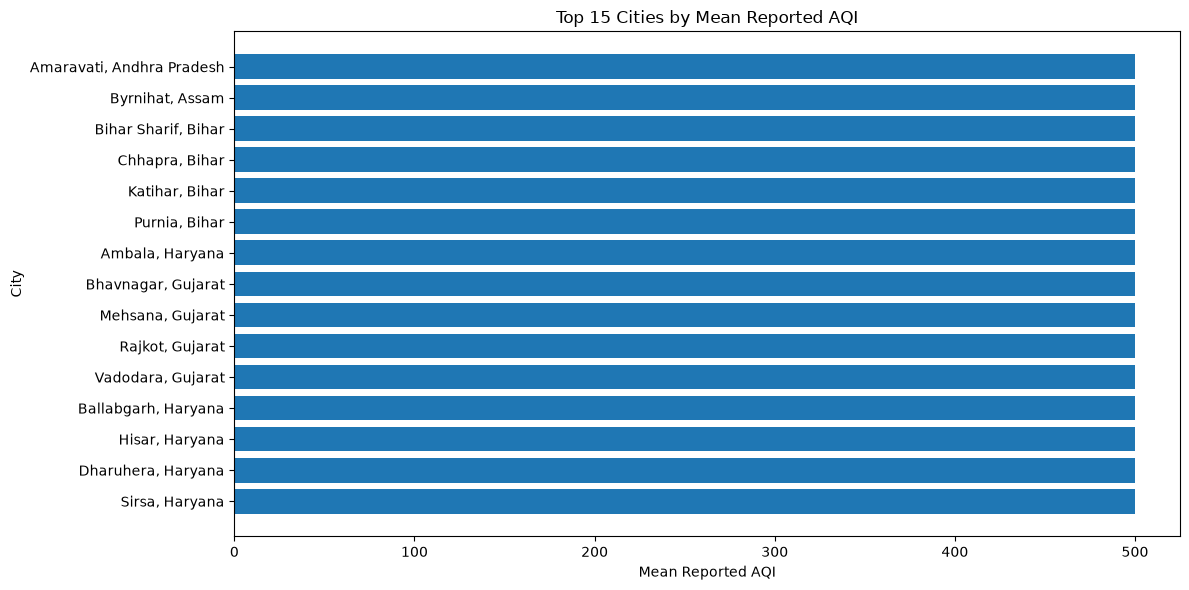

Saved plot: C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_cities_by_mean_aqi.png


In [29]:
top_cities = (
    city_summary
    .dropna(subset=["mean_aqi"])
    .sort_values("mean_aqi", ascending=False)
    .head(15)
    .copy()
)

if top_cities.empty:
    print("No valid city AQI values available for plotting.")
else:
    plt.figure(figsize=(12, 6))

    plt.barh(
        top_cities["city"] + ", " + top_cities["state"],
        top_cities["mean_aqi"]
    )

    plt.xlabel("Mean Reported AQI")
    plt.ylabel("City")
    plt.title("Top 15 Cities by Mean Reported AQI")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    TOP_CITIES_PLOT_PATH = OUTPUTS_DIR / "top_cities_by_mean_aqi.png"

    plt.savefig(
        TOP_CITIES_PLOT_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved plot:", TOP_CITIES_PLOT_PATH)

In [30]:
run_summary = {
    "notebook": "01_live_aqi_data_fetching.ipynb",
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "raw_records": int(len(raw_df)),
    "clean_long_records": int(len(aqi_long)),
    "station_level_records": int(len(station_df)),
    "unique_stations": int(station_df["station_id"].nunique()),
    "unique_cities": int(station_df["city"].nunique()),
    "unique_states": int(station_df["state"].nunique()),
    "valid_aqi_stations": int(station_df["aqi_is_valid"].sum()),
    "invalid_aqi_stations": int((~station_df["aqi_is_valid"]).sum()),
    "history_records": int(len(combined_history)),
    "latest_file": str(LATEST_PATH),
    "history_file": str(HISTORY_PATH),
    "city_summary_file": str(CITY_SUMMARY_PATH)
}

RUN_SUMMARY_PATH = REPORTS_DIR / "notebook_01_run_summary.json"

with open(RUN_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(run_summary, file, indent=4)

print("Run summary saved:")
print(RUN_SUMMARY_PATH)

print(json.dumps(run_summary, indent=4))

Run summary saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\reports\notebook_01_run_summary.json
{
    "notebook": "01_live_aqi_data_fetching.ipynb",
    "run_time": "2026-07-16 05:38:20",
    "raw_records": 3507,
    "clean_long_records": 3220,
    "station_level_records": 500,
    "unique_stations": 500,
    "unique_cities": 264,
    "unique_states": 29,
    "valid_aqi_stations": 478,
    "invalid_aqi_stations": 22,
    "history_records": 6072,
    "latest_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\data\\processed\\station_intelligence_latest.csv",
    "history_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\data\\processed\\station_aqi_history.csv",
    "city_summary_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\data\\processed\\city_aqi_summary_latest.csv"
}


In [31]:
required_output_files = [
    LATEST_PATH,
    HISTORY_PATH,
    CITY_SUMMARY_PATH,
    CLEAN_LONG_PATH,
    RUN_SUMMARY_PATH
]

if "TOP_CITIES_PLOT_PATH" in globals():
    required_output_files.append(TOP_CITIES_PLOT_PATH)

missing_files = [
    path for path in required_output_files
    if not path.exists()
]

if missing_files:
    print("Missing files:")

    for path in missing_files:
        print(path)

    raise FileNotFoundError("Some expected output files were not created.")

print("Notebook 01 completed successfully.")
print("Created files:")

for path in required_output_files:
    print("-", path)

Notebook 01 completed successfully.
Created files:
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_intelligence_latest.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_aqi_history.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\city_aqi_summary_latest.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\raw\cpcb_aqi_clean_long.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\reports\notebook_01_run_summary.json
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_cities_by_mean_aqi.png
